Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8732 - loss: 0.4359 - val_accuracy: 0.9535 - val_loss: 0.1613
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9669 - loss: 0.1168 - val_accuracy: 0.9684 - val_loss: 0.1030
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0750 - val_accuracy: 0.9730 - val_loss: 0.0873
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9858 - loss: 0.0504 - val_accuracy: 0.9785 - val_loss: 0.0674
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9895 - loss: 0.0365 - val_accuracy: 0.9794 - val_loss: 0.0640
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9921 - loss: 0.0281 - val_accuracy: 0.9816 - val_loss: 0.0602
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9941 - loss: 0.0208 - val_accuracy: 0.9822 - val_loss: 0.0605
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9967 - loss: 0.0148 - val_accu

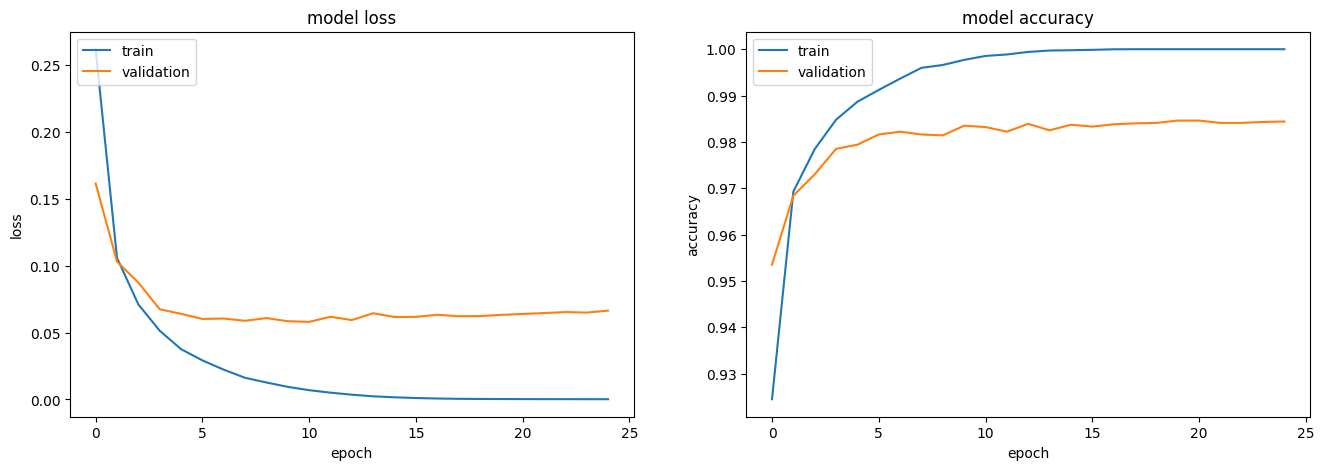

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
[3.9438418e-13, 1.9936341e-10, 1.0, 4.3409473e-10, 1.4666512e-20, 4.2690274e-14, 2.0189868e-13, 1.6748506e-23, 2.1907527e-10, 6.211515e-22]
Number is  2 (probability 100.0000)


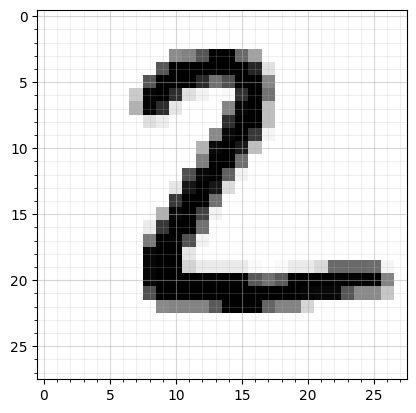

In [2]:
# 만들어진 모델에 대해 loss, accuracy 를 그래프로 표현
def display_graph():
    plt.figure(figsize=(16,5))

    # 만들어진 모델에 대해 train dataset과 validation dataset의 loss 를 그래프로 표현해 봅니다.
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')

    # 만들어진 모델에 대해 train dataset과 validation dataset의 accuracy 를 그래프로 표현해 봅니다.
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')

    plt.show()

# 특정한 숫자(digit)의 이미지를 Display 해주는 함수 정의
def show_digit_image(image):
    # Draw digit image
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    # Major ticks every 20, minor ticks every 5
    major_ticks = np.arange(0, 29, 5)
    minor_ticks = np.arange(0, 29, 1)
    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.set_yticks(major_ticks)
    ax.set_yticks(minor_ticks, minor=True)
    # And a corresponding grid
    ax.grid(which='both')
    # Or if you want different settings for the grids:
    ax.grid(which='minor', alpha=0.2)
    ax.grid(which='major', alpha=0.5)
    ax.imshow(image, cmap=plt.cm.binary)

    plt.show()

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential

t_t = 100  # training 횟수(epoch)
num_classes = 10  # 분류하고자 하는 숫자가 총 10개(0 ~ 9)

# Keras Datasets 에서 제공하는 MNIST dataset을 불러옵니다.
from tensorflow.keras.datasets import mnist
# MNIST dataset을 불러와서 train dataset과 test dataset에 넣어 줍니다.
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 모델 구성하기
model = Sequential()
model.add(Input(shape=(28 * 28,)))  # Input 레이어 추가
model.add(Dense(512, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# 모델 학습과정 설정하기
model.compile(loss='categorical_crossentropy',
                optimizer='rmsprop',
                metrics=['accuracy'])

# 모델 구성 확인하기
model.summary()

x_train = x_train.reshape((60000, 28 * 28)) # Reshape
x_train = x_train.astype('float32') / 255   # Feature Scaling(0 ~ 1 사이의 값으로 Data Preprocessing)


x_test_original = x_test  # test data(이미지) 복사
x_test = x_test.reshape((10000, 28 * 28))  # Reshape
x_test = x_test.astype('float32') / 255    # Feature Scaling(0 ~ 1 사이의 값으로 Data Preprocessing)

# One Hot label로 변경해 주는 패키지를 불러옵니다.
from tensorflow.keras.utils import to_categorical

# label를 One Hot 구조로 변경
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# EarlyStopping 기능과 ModelCheckpoint 기능을 사용하기 위해 패키지를 불러옵니다.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 모델이 가장 best일때 모델을 저장하도록 설정
modelCheckpoint = ModelCheckpoint('best_digits_model.keras', save_best_only=True)

# val_acc 를 모니터링 하다가 조기에 학습을 종료하도록 설정
monitor_val_acc = EarlyStopping(monitor='val_accuracy',
                        patience=5)

# 모델 학습시키기
history = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=t_t, batch_size=128,
                    callbacks=[monitor_val_acc, modelCheckpoint])   # callbacks에 EarlyStopping, ModelCheckpoint 설정

# 그래프 출력
display_graph()

# 예측하기
selected_image = 1
result = model.predict(np.array([x_test[selected_image]]))  # result 에는 One hot encoding 형식으로 결과가 들어있음
result_number = np.argmax(result)   # argmax 함수를 사용해 One hot encoding 형식의 결과값 중 가장 큰 값의 index 를 반환

# 예측결과 출력
performance = [val for val in result[0]]
print(performance)
result_probability = performance[result_number]
print("Number is %2i (probability %7.4f)" % (result_number, result_probability*100))
show_digit_image(x_test_original[selected_image])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[3.6947086e-15, 1.0356974e-13, 2.7349637e-12, 2.164676e-06, 1.02768694e-16, 0.99999785, 7.92166e-15, 2.0987359e-14, 3.8691793e-11, 3.236314e-10]
Number is  5 (probability 99.9998)


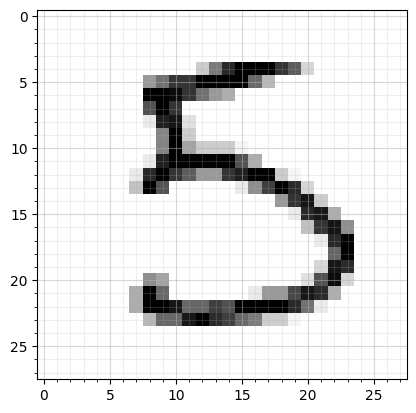

In [3]:
# 예측하기
selected_image = 15
result = model.predict(np.array([x_test[selected_image]]))  # result 에는 One hot encoding 형식으로 결과가 들어있음
result_number = np.argmax(result)   # argmax 함수를 사용해 One hot encoding 형식의 결과값 중 가장 큰 값의 index 를 반환

# 예측결과 출력
performance = [val for val in result[0]]
print(performance)
result_probability = performance[result_number]
print("Number is %2i (probability %7.4f)" % (result_number, result_probability*100))
show_digit_image(x_test_original[selected_image])